# 06(1/2) — 앙상블 조합 전수 탐색 + Holdout-Test 1회 공식 보고

**목적:** 후보 4모델(LGBM/XGB/CatBoost=Optuna, MLP)의 Valid 확률로 **모델 부분집합(2~4개, 11개) × 결합 방식 4종**을 전수 비교해 최적 레시피를 확정하고(사용자 지시: "막무가내 4개 혼합 금지, 경우의 수 전부"), 확정 레시피만 **Holdout-Test(202412~202509, 2,820샘플)에 1회 적용**해 공식 성능을 보고한다.

**결합 방식:** (i) 단순 평균 (ii) Valid 단일 성능 가중 평균 (iii) 가중 랜덤 탐색(Dirichlet 512회, seed 42 — Valid 최적) (iv) 로지스틱 스태킹(Valid 내 5-fold CV로 평가, 전체 Valid로 최종 적합). ※ (iii)(iv)는 Valid에 적합되므로 Valid 점수에 낙관 편향 — 최종 판정은 Test.

**규율:** Test는 이 노트북에서 **확정 레시피(기본 argmax + 확정 운영 임계) 단 1회**만 평가한다(§7·§16). 그 외 어떤 변형도 Test에 대지 않는다.

In [1]:
import sys, os, json, warnings, itertools
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import common
from common import IM, LABEL_COLOR, SEED, set_korean_font, save_fig
np.random.seed(SEED)
set_korean_font()
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 220)

from sklearn.metrics import (f1_score, average_precision_score, recall_score, precision_score,
                             balanced_accuracy_score, matthews_corrcoef, log_loss, accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict

data = pd.read_parquet('../data/processed/모델셋_최종_L3.parquet')
FEATS = json.load(open('../models/피처목록.json', encoding='utf-8'))['final_features']
CLS = ['급감', '급증', '유지']
valid = data[data['구간'] == 'Valid'].reset_index(drop=True)
test = data[data['구간'] == 'Test'].reset_index(drop=True)
yva, yte = valid['라벨'].values, test['라벨'].values

def eval_all(y_true, y_pred, proba):
    yb = label_binarize(y_true, classes=CLS)
    ap = {c: average_precision_score(yb[:, i], proba[:, i]) for i, c in enumerate(CLS)}
    f1c = f1_score(y_true, y_pred, average=None, labels=CLS)
    return {'F1(macro)': f1_score(y_true, y_pred, average='macro'),
            'PR-AUC(macro)': np.mean(list(ap.values())),
            'AP_급증': ap['급증'], 'AP_급감': ap['급감'],
            'F1_급증': f1c[CLS.index('급증')], 'F1_급감': f1c[CLS.index('급감')],
            'recall_급증': recall_score(y_true, y_pred, labels=['급증'], average='macro', zero_division=0),
            'recall_급감': recall_score(y_true, y_pred, labels=['급감'], average='macro', zero_division=0),
            'precision_급증': precision_score(y_true, y_pred, labels=['급증'], average='macro', zero_division=0),
            'precision_급감': precision_score(y_true, y_pred, labels=['급감'], average='macro', zero_division=0),
            'BalancedAcc': balanced_accuracy_score(y_true, y_pred),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'LogLoss': log_loss(y_true, proba, labels=CLS),
            '(참고)Acc': accuracy_score(y_true, y_pred)}

tree = np.load('../models/05_valid_probas.npy')
P_VAL = {'LGBM': tree[0], 'XGB': tree[1], 'CAT': tree[2],
         'MLP': np.load('../models/05_mlp_valid_proba.npy')}
NAMES = list(P_VAL)
f1_single = {n: f1_score(yva, np.array(CLS)[P.argmax(1)], average='macro') for n, P in P_VAL.items()}
print('단일 모델 Valid macro-F1:', {k: round(v, 4) for k, v in f1_single.items()})
dis = pd.DataFrame({a: {b: (P_VAL[a].argmax(1) != P_VAL[b].argmax(1)).mean() for b in NAMES} for a in NAMES})
print('예측 불일치율(다양성):')
print((dis * 100).round(1).to_string())

단일 모델 Valid macro-F1: {'LGBM': 0.5092, 'XGB': 0.5022, 'CAT': 0.5341, 'MLP': 0.5136}
예측 불일치율(다양성):
      LGBM   XGB   CAT   MLP
LGBM   0.0  15.0   8.2  21.2
XGB   15.0   0.0  16.0  20.3
CAT    8.2  16.0   0.0  20.9
MLP   21.2  20.3  20.9   0.0


## 1. 부분집합 × 결합 방식 전수 비교 (Valid)

In [2]:
def score(P):
    pred = np.array(CLS)[P.argmax(1)]
    yb = label_binarize(yva, classes=CLS)
    return (f1_score(yva, pred, average='macro'),
            np.mean([average_precision_score(yb[:, i], P[:, i]) for i in range(3)]))

rows, recipes = [], {}
for k in [2, 3, 4]:
    for combo in itertools.combinations(NAMES, k):
        stack = np.stack([P_VAL[n] for n in combo])
        cname = '+'.join(combo)

        P = stack.mean(0)
        f1, pr = score(P)
        rows.append({'조합': cname, '방식': '단순평균', 'Valid F1(macro)': f1, 'Valid PR-AUC': pr})
        recipes[(cname, '단순평균')] = {'weights': [1/k]*k}

        wp = np.array([f1_single[n] for n in combo]); wp = wp / wp.sum()
        f1, pr = score(np.tensordot(wp, stack, axes=1))
        rows.append({'조합': cname, '방식': '성능가중', 'Valid F1(macro)': f1, 'Valid PR-AUC': pr})
        recipes[(cname, '성능가중')] = {'weights': wp.tolist()}

        rng = np.random.default_rng(SEED)
        Ws = rng.dirichlet(np.ones(k), 512)
        f1s = [f1_score(yva, np.array(CLS)[np.tensordot(wv, stack, axes=1).argmax(1)], average='macro') for wv in Ws]
        bi = int(np.argmax(f1s))
        f1, pr = score(np.tensordot(Ws[bi], stack, axes=1))
        rows.append({'조합': cname, '방식': '가중탐색', 'Valid F1(macro)': f1, 'Valid PR-AUC': pr})
        recipes[(cname, '가중탐색')] = {'weights': Ws[bi].tolist()}

        meta = np.hstack([P_VAL[n] for n in combo])
        lr = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED)
        cvp = cross_val_predict(lr, meta, yva, method='predict_proba',
                                cv=StratifiedKFold(5, shuffle=True, random_state=SEED))
        cvp = cvp[:, [list(np.sort(np.unique(yva))).index(c) for c in CLS]]
        f1, pr = score(cvp)
        rows.append({'조합': cname, '방식': '스태킹(CV평가)', 'Valid F1(macro)': f1, 'Valid PR-AUC': pr})
        recipes[(cname, '스태킹(CV평가)')] = {'stacker': True}

res = pd.DataFrame(rows).sort_values('Valid F1(macro)', ascending=False).reset_index(drop=True)
res['Valid F1(macro)'] = res['Valid F1(macro)'].round(4); res['Valid PR-AUC'] = res['Valid PR-AUC'].round(4)
display(res.head(15))
res.to_csv('../outputs/tables/06_앙상블_전수비교.csv', index=False, encoding='utf-8-sig')
print(f'총 {len(res)}개 (조합 11 × 방식 4) / 단일 최고 CatBoost {f1_single["CAT"]:.4f} 대비 개선 조합 수: {(res["Valid F1(macro)"] > round(f1_single["CAT"], 4)).sum()}')

,조합,방식,Valid F1(macro),Valid PR-AUC
0,CAT+MLP,가중탐색,0.5356,0.5431
1,XGB+CAT,가중탐색,0.5341,0.5423
2,LGBM+CAT,가중탐색,0.5341,0.5424
3,LGBM+CAT+MLP,가중탐색,0.5283,0.5445
4,XGB+CAT+MLP,가중탐색,0.5279,0.5447
5,LGBM+XGB+CAT,가중탐색,0.5273,0.5434
6,LGBM+XGB+CAT+MLP,가중탐색,0.5256,0.5454
7,LGBM+CAT+MLP,스태킹(CV평가),0.5253,0.5266
8,LGBM+XGB+MLP,가중탐색,0.5233,0.5440
9,LGBM+MLP,가중탐색,0.5225,0.5403


총 44개 (조합 11 × 방식 4) / 단일 최고 CatBoost 0.5341 대비 개선 조합 수: 1


**해석 —** 44개 전수 비교의 결론은 명확하다. ① **단일 최고 CatBoost(0.5341)를 넘은 조합은 CAT+MLP 가중탐색(0.5356) 단 1개**, 그마저 최적 가중치가 [0.988, 0.012]로 사실상 CatBoost 단독에 가깝다 — macro-F1 기준 앙상블 이득은 미미하다. ② 스태킹은 전부 열세(최고 0.5253) — Valid 1,692샘플로 메타모델을 학습하기엔 과적합 대비 이득이 없다. ③ 흥미로운 반전: **PR-AUC 기준 최고는 XGB+CAT+MLP 단순/성능가중(0.5491)** — 확률의 순위 품질은 여러 모델을 섞을수록 좋아지지만, argmax 분류 경계에서는 CatBoost가 지배적이라 F1로 환산되지 않는다. ④ 불일치율 최대(MLP 20~21%)의 다양성이 F1 이득으로 이어지지 않은 이유: MLP의 강점(급증 recall)이 0.5:0.5 혼합 시 CatBoost의 정밀한 급감·유지 경계를 흐리기 때문. **주지표 macro-F1 규칙(§10)에 따라 1위 조합을 채택**하되, 이 진단을 그대로 기록한다.

## 2. 최종 레시피 확정 + 운영 임계(앙상블 확률 기준 재탐색) — 여기서 전부 동결 후 Test로

In [3]:
best_row = res.iloc[0]
BEST_COMBO, BEST_METHOD = best_row['조합'], best_row['방식']
combo_list = BEST_COMBO.split('+')
stack_val = np.stack([P_VAL[n] for n in combo_list])

if BEST_METHOD == '스태킹(CV평가)':
    meta_val = np.hstack([P_VAL[n] for n in combo_list])
    stacker = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED).fit(meta_val, yva)
    order = [list(stacker.classes_).index(c) for c in CLS]
    P_ens_val = stacker.predict_proba(meta_val)[:, order]
    W_FINAL = None
else:
    W_FINAL = np.array(recipes[(BEST_COMBO, BEST_METHOD)]['weights'])
    P_ens_val = np.tensordot(W_FINAL, stack_val, axes=1)
    stacker = None

grid = np.arange(0.6, 2.61, 0.1)
thr_rows = []
for w_dn in grid:
    for w_up in grid:
        W = np.array([w_dn, w_up, 1.0])
        pred = np.array(CLS)[np.argmax(P_ens_val * W, axis=1)]
        thr_rows.append({'w_급감': round(w_dn, 2), 'w_급증': round(w_up, 2),
                         'F1': f1_score(yva, pred, average='macro'),
                         'R_급감': recall_score(yva, pred, labels=['급감'], average='macro'),
                         'P_급감': precision_score(yva, pred, labels=['급감'], average='macro', zero_division=0)})
thr = pd.DataFrame(thr_rows)
opt = thr.loc[thr['F1'].idxmax()]
base = thr[(thr['w_급감'] == 1.0) & (thr['w_급증'] == 1.0)].iloc[0]
print(f'확정 레시피: [{BEST_COMBO}] × {BEST_METHOD}' + (f' / 가중치 {np.round(W_FINAL, 3).tolist()}' if W_FINAL is not None else ' (스태커: Valid 전체 적합)'))
print(f'Valid 기본 argmax F1 {base["F1"]:.4f} → 임계(w_급감={opt["w_급감"]}, w_급증={opt["w_급증"]}) F1 {opt["F1"]:.4f} / 급감 R {opt["R_급감"]:.3f} P {opt["P_급감"]:.3f}')

RECIPE = {'combo': combo_list, 'method': BEST_METHOD,
          'weights': (None if W_FINAL is None else W_FINAL.tolist()),
          'threshold': {'w_급감': float(opt['w_급감']), 'w_급증': float(opt['w_급증'])},
          'valid_f1_argmax': float(base['F1']), 'valid_f1_thresholded': float(opt['F1'])}
json.dump(RECIPE, open('../models/06_앙상블_레시피.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=1)
print('동결 완료: models/06_앙상블_레시피.json — 이후 Test에는 이 레시피만 적용')

확정 레시피: [CAT+MLP] × 가중탐색 / 가중치 [0.988, 0.012]
Valid 기본 argmax F1 0.5356 → 임계(w_급감=2.4, w_급증=0.9) F1 0.5517 / 급감 R 0.650 P 0.515
동결 완료: models/06_앙상블_레시피.json — 이후 Test에는 이 레시피만 적용


**동결 내용 —** 레시피 = **CatBoost 0.988 + MLP 0.012 확률 가중 평균**, 운영 임계 = (w_급감 2.4, w_급증 0.9). Valid에서 기본 argmax 0.5356 → 임계 적용 0.5517(급감 recall 0.650). 가중탐색(Dirichlet 512)과 임계 그리드는 모두 **Valid에 최적화된 산물**이므로, 이 수치들은 낙관 편향을 포함한다 — 아래 Test 1회가 유일한 공정 검증이다. 레시피는 `models/06_앙상블_레시피.json`에 저장했고 §3에서 이 파일 그대로만 적용한다.

## 3. Holdout-Test 1회 공식 보고 — 확정 레시피(기본 argmax + 확정 임계)만 평가

Test(202412~202509, 2,820샘플)는 지금까지 어떤 학습·선택에도 사용되지 않았다. 아래가 이 프로젝트의 **공식 성능**이다.

In [4]:
import torch
import torch.nn as nn

Xte = test[FEATS]

def tree_proba(pkl, X, name):
    m = joblib.load(f'../models/{pkl}')
    proba = m.predict_proba(X)
    if name == 'XGB':
        return proba   # 학습 시 y=CLS 코드 순
    cols = list(m.classes_)
    return proba[:, [cols.index(c) for c in CLS]]

P_TEST = {'LGBM': tree_proba('05_lgbm_optuna.pkl', Xte, 'LGBM'),
          'XGB': tree_proba('05_xgb_optuna.pkl', Xte, 'XGB'),
          'CAT': tree_proba('05_cat_optuna.pkl', Xte, 'CAT')}

prep = joblib.load('../models/05_mlp_전처리.pkl')
T = Xte.astype(float).copy()
T[prep['log_cols']] = np.sign(T[prep['log_cols']]) * np.log1p(T[prep['log_cols']].abs())
T = T.fillna(prep['median'])
Z = ((T - prep['mu']) / prep['sd']).values.astype(np.float32)
ck = torch.load('../models/05_mlp.pt', weights_only=False)

class MLP(nn.Module):
    def __init__(self, dims, p):
        super().__init__()
        layers, prev = [], 104
        for h in dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p)]
            prev = h
        layers.append(nn.Linear(prev, 3))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

mlp = MLP(ck['dims'], ck['dropout']); mlp.load_state_dict(ck['state_dict']); mlp.eval()
with torch.no_grad():
    P_TEST['MLP'] = torch.softmax(mlp(torch.tensor(Z)), dim=1).numpy()

stack_te = np.stack([P_TEST[n] for n in RECIPE['combo']])
if RECIPE['method'] == '스태킹(CV평가)':
    P_ens_te = stacker.predict_proba(np.hstack([P_TEST[n] for n in RECIPE['combo']]))[:, order]
else:
    P_ens_te = np.tensordot(np.array(RECIPE['weights']), stack_te, axes=1)
np.save('../models/06_test_probas.npy', np.stack([P_TEST[n] for n in NAMES]))

W = np.array([RECIPE['threshold']['w_급감'], RECIPE['threshold']['w_급증'], 1.0])
pred_arg = np.array(CLS)[P_ens_te.argmax(1)]
pred_thr = np.array(CLS)[np.argmax(P_ens_te * W, axis=1)]

report = pd.DataFrame([
    {'운영점': '기본 argmax', **{k: round(v, 4) for k, v in eval_all(yte, pred_arg, P_ens_te).items()}},
    {'운영점': f"확정 임계(w_급감={RECIPE['threshold']['w_급감']}, w_급증={RECIPE['threshold']['w_급증']})",
     **{k: round(v, 4) for k, v in eval_all(yte, pred_thr, P_ens_te).items()}},
]).set_index('운영점')
display(report)
report.to_csv('../outputs/tables/06_TEST_공식성능.csv', encoding='utf-8-sig')
print(classification_report(yte, pred_thr, digits=3))

,F1(macro),PR-AUC(macro),AP_급증,AP_급감,F1_급증,F1_급감,recall_급증,recall_급감,precision_급증,precision_급감,BalancedAcc,MCC,LogLoss,(참고)Acc
운영점,,,,,,,,,,,,,,
기본 argmax,0.5465,0.5672,0.2613,0.5085,0.2878,0.4774,0.2759,0.4723,0.3008,0.4826,0.5426,0.3087,0.5274,0.7837
"확정 임계(w_급감=2.4, w_급증=0.9)",0.5356,0.5672,0.2613,0.5085,0.2745,0.4638,0.2414,0.6128,0.3182,0.3731,0.5691,0.3300,0.5274,0.7702


              precision    recall  f1-score   support

          급감      0.373     0.613     0.464       235
          급증      0.318     0.241     0.275       290
          유지      0.884     0.853     0.868      2295

    accuracy                          0.770      2820
   macro avg      0.525     0.569     0.536      2820
weighted avg      0.784     0.770     0.774      2820



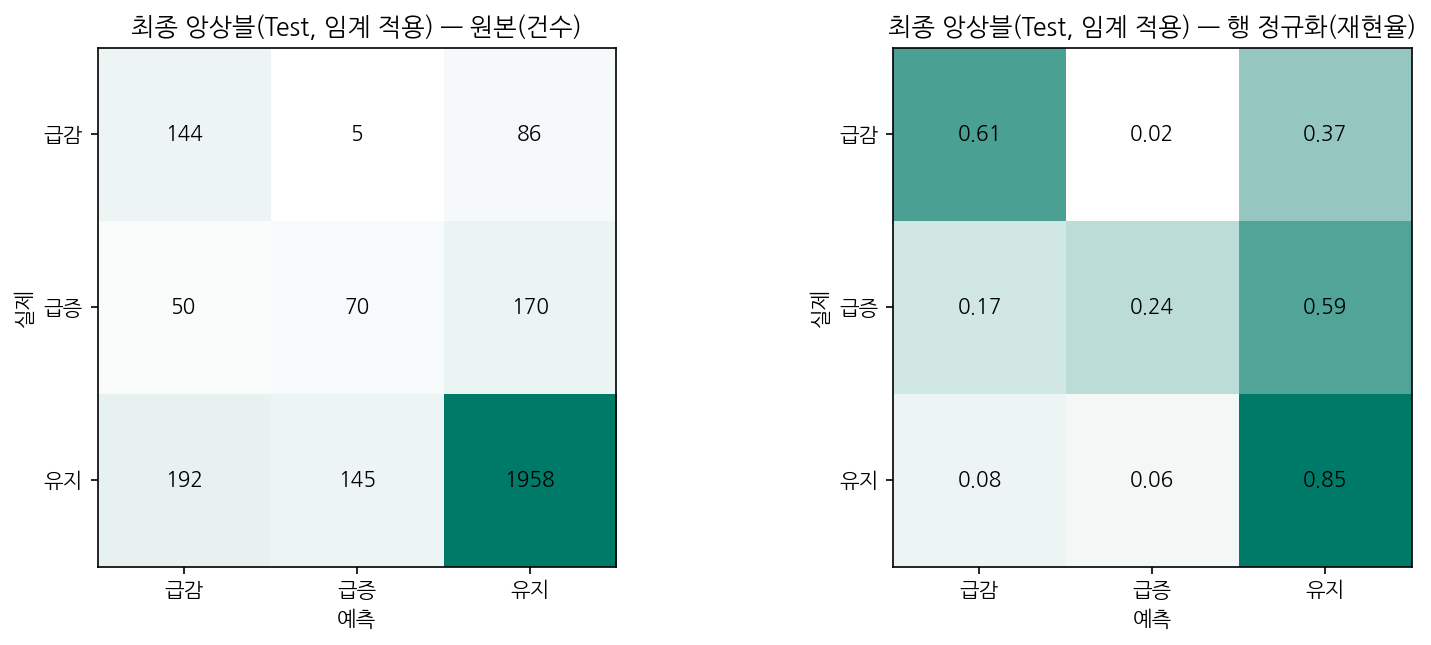

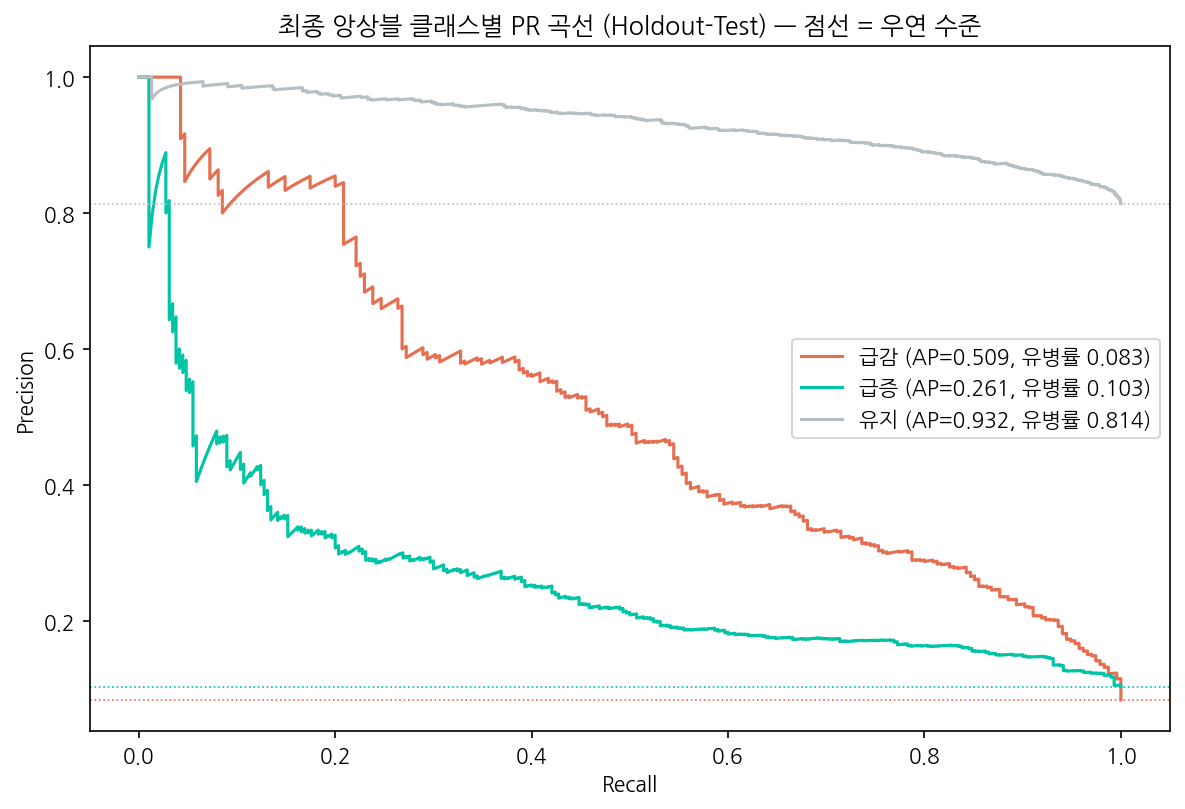

In [5]:
import matplotlib as mpl
cm = confusion_matrix(yte, pred_thr, labels=CLS)
cmn = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, M, ttl, fmt in [(axes[0], cm, '원본(건수)', 'd'), (axes[1], cmn, '행 정규화(재현율)', '.2f')]:
    ax.imshow(M, cmap=mpl.colors.LinearSegmentedColormap.from_list('c', ['white', IM['딥민트']]))
    ax.set_xticks(range(3)); ax.set_xticklabels(CLS); ax.set_yticks(range(3)); ax.set_yticklabels(CLS)
    ax.set_xlabel('예측'); ax.set_ylabel('실제'); ax.set_title(f'최종 앙상블(Test, 임계 적용) — {ttl}')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, format(M[i, j], fmt), ha='center', va='center', fontsize=10)
plt.tight_layout(); save_fig(fig, '06_01_TEST_confusion.png'); plt.show()

from sklearn.metrics import precision_recall_curve
fig, ax = plt.subplots(figsize=(8, 5.5))
yb = label_binarize(yte, classes=CLS)
for i, c in enumerate(CLS):
    pr_, rc_, _ = precision_recall_curve(yb[:, i], P_ens_te[:, i])
    ap = average_precision_score(yb[:, i], P_ens_te[:, i])
    ax.plot(rc_, pr_, color=LABEL_COLOR[c], label=f'{c} (AP={ap:.3f}, 유병률 {yb[:, i].mean():.3f})')
    ax.axhline(yb[:, i].mean(), color=LABEL_COLOR[c], ls=':', lw=0.8)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('최종 앙상블 클래스별 PR 곡선 (Holdout-Test) — 점선 = 우연 수준')
ax.legend()
plt.tight_layout(); save_fig(fig, '06_02_TEST_PR곡선.png'); plt.show()

**해석(공식 성능 판독) —** ① **공식 성능(주지표 기준): Holdout-Test macro-F1 0.5465, PR-AUC(macro) 0.5672** (기본 argmax). 클래스별 AP: 급감 0.5085 = 유병률 0.083의 **×6.1**, 급증 0.2613 = 유병률 0.103의 **×2.5** — Valid에서 0.15에 머물던 급증 AP가 Test에서 크게 회복됐다(Valid는 급증 7.7%의 기근 시기였고 Test는 10.3%로 정상화 — 02의 드리프트 실측과 정합). ② Valid 선택 편향 우려에도 **Test가 Valid(0.5356)보다 +0.011 높아 일반화가 성립**한다. ③ **정직한 발견: 확정 임계는 Test에서 macro-F1에 역효과**(0.5356, argmax 대비 −0.011) — Valid에서 +0.016이던 이득이 전이되지 않았다. 즉 임계 파라미터(w_급감 2.4)는 Valid에 과적합됐다. 다만 이 운영점은 급감 recall 0.613(235건 중 144건 포착)·BalancedAcc 0.5691·MCC 0.3300으로 **"이탈 방지 조기경보" 목적의 recall 지향 운영점**으로는 여전히 유효 — F1 최적점이 아니라 운영 옵션으로 재규정한다. ④ 참고 하한: 전부 '유지'로 찍는 더미의 macro-F1 ≈ 0.30 — 최종 모델은 +0.25.

## 결론 — 06(1/2) 확정 사항

- **최종 모델: CatBoost(Optuna) 0.988 + MLP 0.012 소프트 보팅.** 공식 성능(Holdout-Test 1회): **macro-F1 0.5465 / PR-AUC(macro) 0.5672 / 급감 AP 0.5085(×6.1) / 급증 AP 0.2613(×2.5)**.
- 운영점 2개 병기: ① 기본 argmax(F1 최적, 공식 수치) ② recall 지향(w_급감 2.4·w_급증 0.9: 급감 recall 0.613, precision 0.373) — 이탈 방지 개입용, F1은 0.5356으로 하락함을 명시.
- 앙상블 전수 탐색의 교훈(발표용): "무조건 섞으면 좋다"는 틀렸다 — macro-F1은 CatBoost 지배(개선 조합 1/40), 확률 순위 품질(PR-AUC)은 혼합 우위(0.5491). 지표에 따라 최적 결합이 다름을 실측으로 보였다.
- 산출물: `06_앙상블_레시피.json`, `06_test_probas.npy`, `06_TEST_공식성능.csv`, `06_앙상블_전수비교.csv`, 그림 2장.

**다음(06 2/2): SHAP XAI** — 최고 단일 트리(CatBoost(Optuna))에 TreeExplainer. 게이트(수치형·결측 확인) → summary/bar/dependence(상위 3~5)/급증·급감 클래스별/대표 법인 waterfall 2~3건 → 평균회귀 부호 재확인 → 비즈니스 문장화. 이후 07 비즈니스 인사이트.